In [4]:
# import sqlite3

# conn = sqlite3.connect("/teamspace/studios/this_studio/Airport-AI/database/airport_monitor.db")
# cursor = conn.cursor()

# cursor.execute("PRAGMA table_info(events)")
# print(cursor.fetchall())

# conn.close()

In [5]:
# =====================
# Test Environment Setup
# =====================


# Model will download automatically into Ultralytic cache
# model = YOLO("yolov8n.pt") 

In [6]:
# ===================
# Test the Setup Model
# ===================
# import numpy as np

# img = np.zeros((640, 640, 3), dtype=np.uint8)
# results = model(img)
# results

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
# from ultralytics import YOLO

# class YOLODetector:
#     def __init__(self, model_path: str):
#         self.model = YOLO(model_path)

#     def predict(self, frame):
#         results = self.model.predict(
#             frame,
#             verbose=False,
#             conf=0.35
#         )
#         return results[0]

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

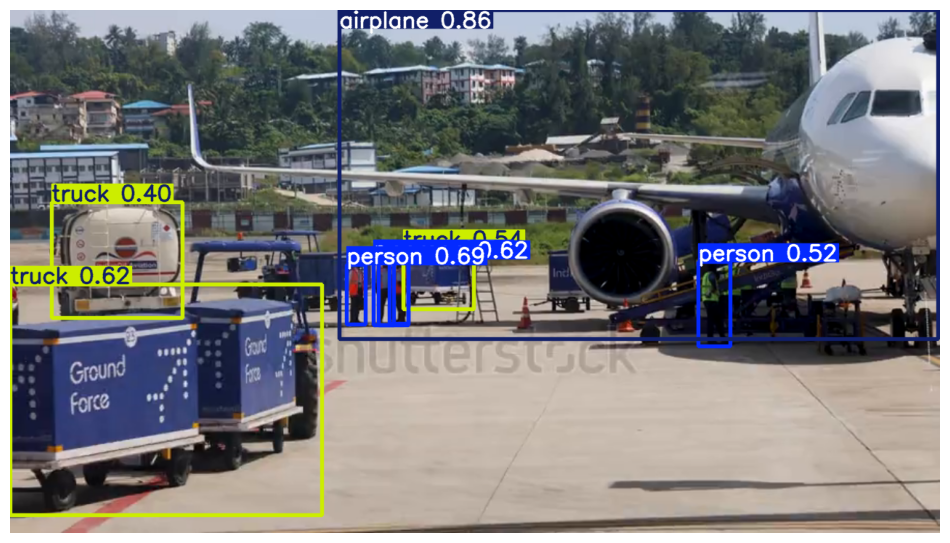

In [9]:
# =======================
# Test Inference Scripts
# =======================
import sys
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.getcwd()).parent
# Connect to custom-defined modules
sys.path.append(str(PROJECT_ROOT))

from airport_ai.streams.camera import AsyncCamera
from airport_ai.inference.detector import YOLODetector
from airport_ai.inference.parser import DetectionParser
from airport_ai.config.settings import *

camera = AsyncCamera(
    source=VIDEO_SOURCE,
    width=FRAME_WIDTH,
    height=FRAME_HEIGHT,
    queue_size=FRAME_QUEUE_SIZE,
).start()

detector = YOLODetector(str(PROJECT_ROOT/"models/yolov8n.pt"))
detector_parser = DetectionParser()

""" Window Not Opening"""
# while True:
#     frame = camera.read()
#     result = detector.predict(frame)
#     detections = parser.parse(result)
#     annotated = result.plot()
#     cv2.imshow("YOLO Detection", annotated)
#     print("-"*40)
#     for detection in detections:
#         print(detection)
#     if cv2.waitKey(1) == ord("q"):
#         break
# camera.stop()
# cv2.destroyAllWindows()

frame = camera.read()
detector_result = detector.predict(frame)
detections = detector_parser.parse(detector_result)
detector_annotated = detector_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(detector_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [10]:
for detection in detections:
    print(detection)

Detection(class_id=4, class_name='airplane', confidence=0.8572530150413513, x1=453.2266845703125, y1=1.8099365234375, x2=1277.65283203125, y2=453.24493408203125, center_x=865.4397583007812, center_y=227.52743530273438, width=824.4261474609375, height=451.43499755859375)
Detection(class_id=0, class_name='person', confidence=0.6923566460609436, x1=463.25054931640625, y1=351.1398620605469, x2=489.42340087890625, y2=433.9648132324219, center_x=476.33697509765625, center_y=392.5523376464844, width=26.1728515625, height=82.824951171875)
Detection(class_id=0, class_name='person', confidence=0.6186248660087585, x1=522.8250732421875, y1=343.6319885253906, x2=548.2674560546875, y2=432.8337097167969, center_x=535.5462646484375, center_y=388.23284912109375, width=25.4423828125, height=89.20172119140625)
Detection(class_id=7, class_name='truck', confidence=0.6181142926216125, x1=0.570709228515625, y1=378.6483154296875, x2=429.8981018066406, y2=695.9525146484375, center_x=215.23440551757812, center_

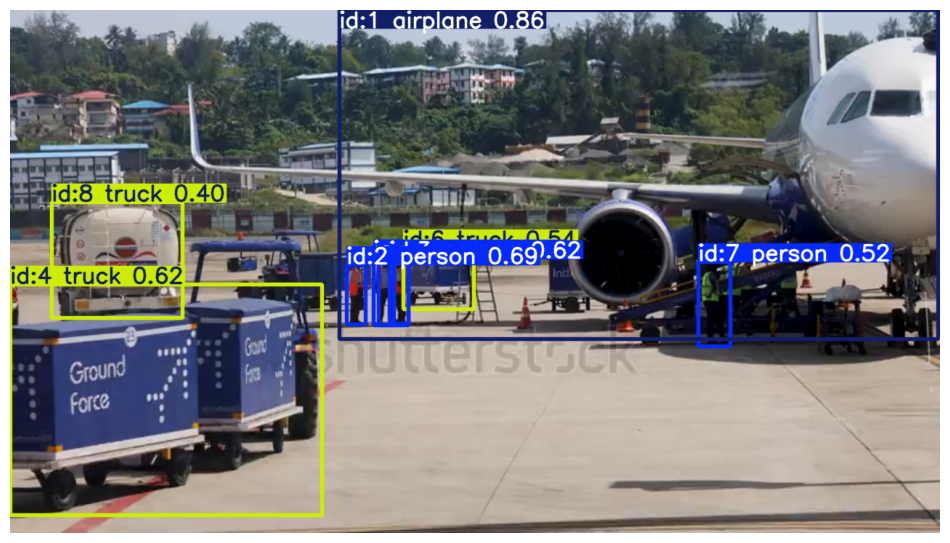

In [11]:
# ==========================
# Test Object Tracking
# ==========================
from airport_ai.tracking.tracker import YOLOTracker
from airport_ai.tracking.parser import TrackingParser

tracker = YOLOTracker(str(PROJECT_ROOT/"models/yolov8n.pt"))
tracker_parser = TrackingParser()

tracker_result = tracker.track(frame)
tracked_objects = tracker_parser.parse(tracker_result)
tracker_annotated = tracker_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(tracker_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [12]:
for obj in tracked_objects:
    print(obj)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8572530150413513, x1=453.2266845703125, y1=1.8099365234375, x2=1277.65283203125, y2=453.24493408203125, center_x=865.4397583007812, center_y=227.52743530273438, width=824.4261474609375, height=451.43499755859375)
TrackedObject(track_id=2, class_id=0, class_name='person', confidence=0.6923566460609436, x1=463.25054931640625, y1=351.1398620605469, x2=489.42340087890625, y2=433.9648132324219, center_x=476.33697509765625, center_y=392.5523376464844, width=26.1728515625, height=82.824951171875)
TrackedObject(track_id=3, class_id=0, class_name='person', confidence=0.6186248660087585, x1=522.8250732421875, y1=343.6319885253906, x2=548.2674560546875, y2=432.8337097167969, center_x=535.5462646484375, center_y=388.23284912109375, width=25.4423828125, height=89.20172119140625)
TrackedObject(track_id=4, class_id=7, class_name='truck', confidence=0.6181142926216125, x1=0.570709228515625, y1=378.6483154296875, x2=429.898101806

In [13]:
# ==============================
# Turnaround Pipeline
# ==============================
# 1. Aircraft Selection
from airport_ai.decision.turnaround.aircraft import AircraftSelector

selector = AircraftSelector()
aircraft = selector.select(tracked_objects)

print(aircraft)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8572530150413513, x1=453.2266845703125, y1=1.8099365234375, x2=1277.65283203125, y2=453.24493408203125, center_x=865.4397583007812, center_y=227.52743530273438, width=824.4261474609375, height=451.43499755859375)


In [17]:
# 2. Safety Zone & Evaluator
from airport_ai.decision.turnaround.zone import SafetyZoneGenerator
from airport_ai.decision.turnaround.evaluator import TurnaroundEvaluator

if aircraft is not None:
    generator = SafetyZoneGenerator(
        margin_x=ZONE_MARGIN_X,
        margin_y=ZONE_MARGIN_Y
    )
    safety_zone = generator.generate(aircraft)
    evaluator = TurnaroundEvaluator(camera_id=None)
    events = evaluator.evaluate(tracked_objects, safety_zone)

for event in events:
    print(event.event_type)
    print(event.message)


Safety Zone Violation
Person 2 entered aircraft safety zone.
Safety Zone Violation
Person 3 entered aircraft safety zone.
Safety Zone Violation
Person 5 entered aircraft safety zone.
Vehicle Zone Violation
Vehicle 6 entered aircraft safety zone.
Safety Zone Violation
Person 7 entered aircraft safety zone.
Safety Zone Violation
Person 9 entered aircraft safety zone.


In [16]:
# 3. Test Visualizer
from airport_ai.decision.turnaround.visualization import TurnaroundVisualizer
visualizer = TurnaroundVisualizer()
frame = visualizer.draw_zone(frame, safety_zone)

In [21]:
# ======================
# Test Storage Script
# ======================
from airport_ai.config.settings import DATABASE_PATH
from airport_ai.storage.database import Database
from airport_ai.storage.schema import DatabaseSchema
from airport_ai.storage.repository import EventRepository

database = Database(DATABASE_PATH)
DatabaseSchema(database).create_tables()
repository = EventRepository(database)

repository.save(None, "TURNAROUND", event)
rows = repository.get_recent()
for row in rows:
    print(row)

(None, '2026-07-28T06:46:09.999938', 'TURNAROUND', 9, 'person', 'Safety Zone Violation', 'HIGH', 'Person 9 entered aircraft safety zone.')


In [22]:
for row in rows:
    print(len(row), row)

8 (None, '2026-07-28T06:46:09.999938', 'TURNAROUND', 9, 'person', 'Safety Zone Violation', 'HIGH', 'Person 9 entered aircraft safety zone.')
